# Assignment 6 (12th June)
Joanna Kusy 275999, Tomasz Srebniak 275987

## Problem 6.1: Transfer Learning (50 points)
Fine-tune pre-trained models:

• Use ResNet50 pre-trained on ImageNet.

• Fine-tune on a small custom image dataset (e.g., Cats vs. Dogs with 500
samples per class).

• Experiment with freezing different numbers of layers.

• Compare with training from scratch.

In [13]:
import os
import random
import copy
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset, ConcatDataset
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.transforms import InterpolationMode
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import pandas as pd
import certifi
import ssl


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


set_seed(42)

os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()
ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

Device: mps


In [9]:
weights = ResNet50_Weights.DEFAULT
if hasattr(weights, "meta") and "mean" in weights.meta and "std" in weights.meta:
    mean = weights.meta["mean"]
    std = weights.meta["std"]
else:
    mean = (0.485, 0.456, 0.406)
    std = (0.229, 0.224, 0.225)

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0), interpolation=InterpolationMode.BILINEAR),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

eval_tf = transforms.Compose([
    transforms.Resize(256, interpolation=InterpolationMode.BILINEAR),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])


def make_pets_dataset(transform):
    root = os.path.join("Assignment6", "data", "oxford_pets")
    trainval = OxfordIIITPet(
        root=root,
        split="trainval",
        target_types="binary-category",
        transform=transform,
        download=True,
    )
    test = OxfordIIITPet(
        root=root,
        split="test",
        target_types="binary-category",
        transform=transform,
        download=True,
    )
    return ConcatDataset([trainval, test])


plain_ds = make_pets_dataset(transform=None)
train_ds_full = make_pets_dataset(transform=train_tf)
eval_ds_full = make_pets_dataset(transform=eval_tf)


def get_targets(ds):
    if hasattr(ds, "targets"):
        return list(ds.targets)
    if hasattr(ds, "_labels"):
        return list(ds._labels)
    targets = []
    for i in range(len(ds)):
        _, y = ds[i]
        targets.append(y)
    return targets


def stratified_split_indices(targets, n_train=500, n_val=250, n_test=250, seed=42):
    rng = np.random.default_rng(seed)
    targets = np.array(targets)
    train_idx, val_idx, test_idx = [], [], []
    for cls in sorted(set(targets)):
        cls_idx = np.where(targets == cls)[0]
        rng.shuffle(cls_idx)
        needed = n_train + n_val + n_test
        if len(cls_idx) < needed:
            raise ValueError(f"Not enough samples for class {cls}: {len(cls_idx)} < {needed}")
        train_idx.extend(cls_idx[:n_train].tolist())
        val_idx.extend(cls_idx[n_train:n_train + n_val].tolist())
        test_idx.extend(cls_idx[n_train + n_val:n_train + n_val + n_test].tolist())
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    rng.shuffle(test_idx)
    return train_idx, val_idx, test_idx


targets = get_targets(plain_ds)
train_idx, val_idx, test_idx = stratified_split_indices(targets)

train_ds = Subset(train_ds_full, train_idx)
val_ds = Subset(eval_ds_full, val_idx)
test_ds = Subset(eval_ds_full, test_idx)

batch_size = 32
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}")

100%|██████████| 792M/792M [00:21<00:00, 37.6MB/s] 
100%|██████████| 19.2M/19.2M [00:00<00:00, 26.2MB/s]


Train: 1000  Val: 500  Test: 500


Unique labels: [0, 1]
Binary labels confirmed: {0: 'cat', 1: 'dog'}
Full dataset counts -> cat: 2371, dog: 4978


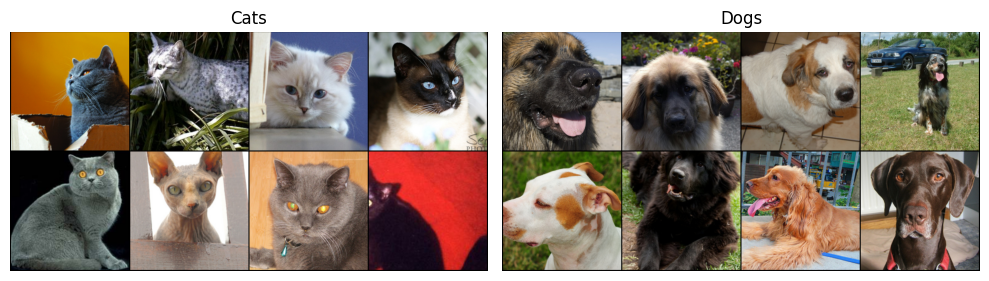

In [17]:
label_map = {0: "cat", 1: "dog"}
unique_labels = sorted(set(targets))
print("Unique labels:", unique_labels)
if set(unique_labels) <= {0, 1}:
    print("Binary labels confirmed:", {i: label_map[i] for i in unique_labels})

label_counts = np.bincount(np.array(targets), minlength=2)
print(f"Full dataset counts -> cat: {label_counts[0]}, dog: {label_counts[1]}")


display_tf = transforms.Compose([
    transforms.Resize(256, interpolation=InterpolationMode.BILINEAR),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])


def sample_indices(targets_list, label, n=8, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.where(np.array(targets_list) == label)[0]
    rng.shuffle(idx)
    return idx[:n]


def grid_from_indices(dataset, indices, nrow=4, transform=None):
    if transform is None:
        transform = display_tf
    imgs = [transform(dataset[i][0]) for i in indices]
    return make_grid(imgs, nrow=nrow)


cat_idx = sample_indices(targets, 0, n=8, seed=42)
dog_idx = sample_indices(targets, 1, n=8, seed=123)

cat_grid = grid_from_indices(plain_ds, cat_idx, nrow=4)
dog_grid = grid_from_indices(plain_ds, dog_idx, nrow=4)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cat_grid.permute(1, 2, 0))
axes[0].set_title("Cats")
axes[1].imshow(dog_grid.permute(1, 2, 0))
axes[1].set_title("Dogs")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [10]:
def normalize_trainable_layers(layers):
    normalized = set()
    if not layers:
        return normalized
    for layer in layers:
        if isinstance(layer, int):
            if layer in (1, 2, 3, 4):
                normalized.add(f"layer{layer}")
        elif isinstance(layer, str):
            name = layer.strip().lower()
            if name in {"fc", "head"}:
                normalized.add("fc")
            elif name.startswith("layer"):
                normalized.add(name)
    return normalized


class ResNet50Wrapper(nn.Module):
    def __init__(self, trainable_layers=None, weights=ResNet50_Weights.DEFAULT, num_classes=2):
        super().__init__()
        self.model = resnet50(weights=weights)
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)
        self.set_trainable_layers(trainable_layers)

    def set_trainable_layers(self, trainable_layers):
        for p in self.model.parameters():
            p.requires_grad = False
        layers = normalize_trainable_layers(trainable_layers)
        layers.add("fc")
        for name, module in self.model.named_children():
            if name in layers:
                for p in module.parameters():
                    p.requires_grad = True

    def forward(self, x):
        return self.model(x)


def train_model(model, dataloaders, criterion, optimizer, device, max_epochs=10, patience=3):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")
    epochs_no_improve = 0

    for epoch in range(1, max_epochs + 1):
        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_correct = 0
            running_total = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad(set_to_none=True)

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                preds = outputs.argmax(dim=1)
                running_correct += (preds == labels).sum().item()
                running_total += labels.size(0)

            epoch_loss = running_loss / running_total
            epoch_acc = running_correct / running_total
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)

        val_loss = history["val_loss"][-1]
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_state)
    return history


def evaluate_accuracy(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total


def plot_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(epochs, history["train_loss"], label="train")
    axes[0].plot(epochs, history["val_loss"], label="val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], label="train")
    axes[1].plot(epochs, history["val_acc"], label="val")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /Users/tomasz/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:02<00:00, 36.8MB/s]


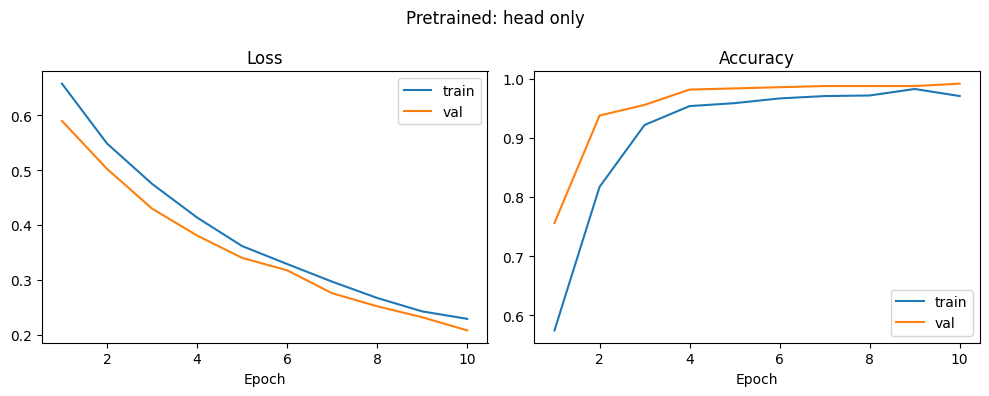

Pretrained: head only test accuracy: 0.9820


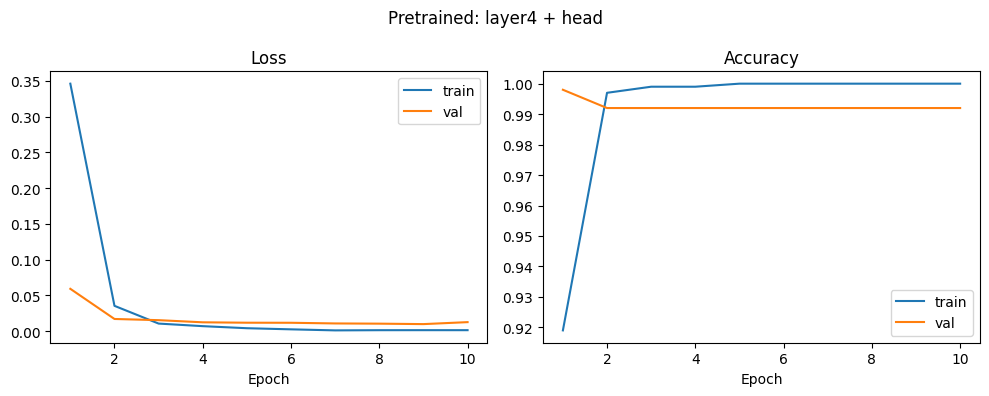

Pretrained: layer4 + head test accuracy: 0.9960
Early stopping at epoch 5


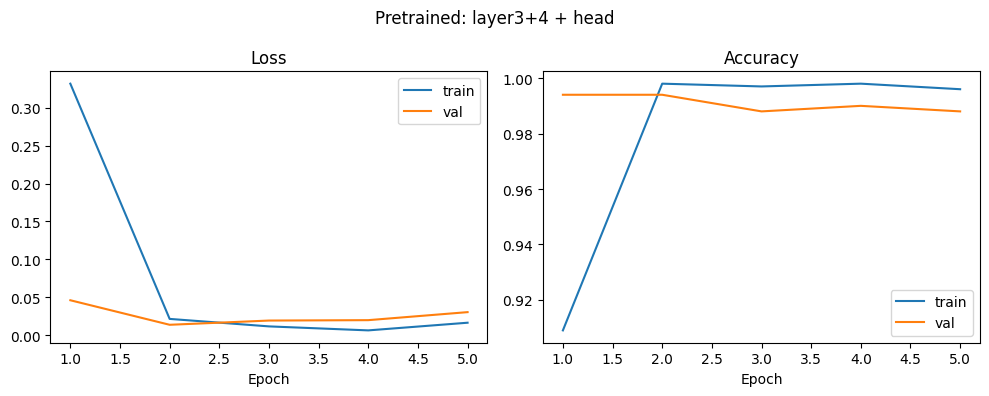

Pretrained: layer3+4 + head test accuracy: 0.9940
Early stopping at epoch 13


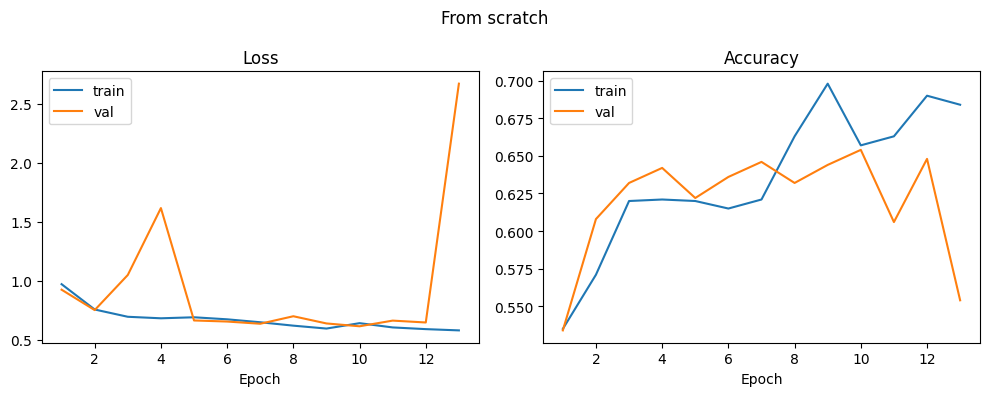

From scratch test accuracy: 0.6520


In [11]:
dataloaders = {"train": train_loader, "val": val_loader}


def run_experiment(name, model, lr=1e-4, max_epochs=10, patience=3):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.Adam(params, lr=lr)
    history = train_model(
        model,
        dataloaders,
        criterion,
        optimizer,
        device,
        max_epochs=max_epochs,
        patience=patience,
    )
    plot_history(history, name)
    test_acc = evaluate_accuracy(model, test_loader, device)
    print(f"{name} test accuracy: {test_acc:.4f}")
    if device.type == "mps":
        torch.mps.empty_cache()
    return history, test_acc


results = {}

model_head_only = ResNet50Wrapper(trainable_layers=[])
results["head_only"] = run_experiment("Pretrained: head only", model_head_only, lr=1e-4)

model_layer4 = ResNet50Wrapper(trainable_layers=[4])
results["layer4_head"] = run_experiment("Pretrained: layer4 + head", model_layer4, lr=1e-4)

model_layer34 = ResNet50Wrapper(trainable_layers=[3, 4])
results["layer3_4_head"] = run_experiment("Pretrained: layer3+4 + head", model_layer34, lr=1e-4)

model_scratch = resnet50(weights=None, num_classes=2)
results["scratch"] = run_experiment("From scratch", model_scratch, lr=1e-3, max_epochs=15)

In [15]:
experiment_info = {
    "head_only": "fc only",
    "layer4_head": "layer4 + fc",
    "layer3_4_head": "layer3-4 + fc",
    "scratch": "all trainable (no pretrain)",
}

rows = []
for key, (history, test_acc) in results.items():
    best_val_acc = max(history["val_acc"]) if history["val_acc"] else None
    best_val_loss = min(history["val_loss"]) if history["val_loss"] else None
    epochs = len(history["train_loss"])
    rows.append({
        "experiment": key,
        "trainable_layers": experiment_info.get(key, ""),
        "epochs": epochs,
        "best_val_acc": round(best_val_acc, 4) if best_val_acc is not None else None,
        "best_val_loss": round(best_val_loss, 4) if best_val_loss is not None else None,
        "test_acc": round(test_acc, 4),
    })

results_df = pd.DataFrame(rows).sort_values("test_acc", ascending=False)
results_df

,experiment,trainable_layers,epochs,best_val_acc,best_val_loss,test_acc
1,layer4_head,layer4 + fc,10,0.998,0.0098,0.996
2,layer3_4_head,layer3-4 + fc,5,0.994,0.0135,0.994
0,head_only,fc only,10,0.992,0.2077,0.982
3,scratch,all trainable (no pretrain),13,0.654,0.6147,0.652


- Pretraining helps a lot on this small dataset: all pretrained variants reach about 0.98 to 0.996 test accuracy, while training from scratch stays around 0.65.
- Unfreezing `layer4` with the head gave the best test accuracy in this run; unfreezing `layer3+4` did not improve and can add overfitting risk.
- Early stopping triggered for some runs, indicating the validation loss stopped improving after a few epochs.

## Problem 6.2: Few-Shot Learning (50 points)
Implement prototypical networks:

• Use Omniglot or mini-ImageNet dataset.

• Implement 5-way 1-shot and 5-way 5-shot classification.

• Calculate episode-wise accuracy.

• Visualize embeddings using t-SNE.

Train classes: 964
Test classes: 659
Images per train class: 20


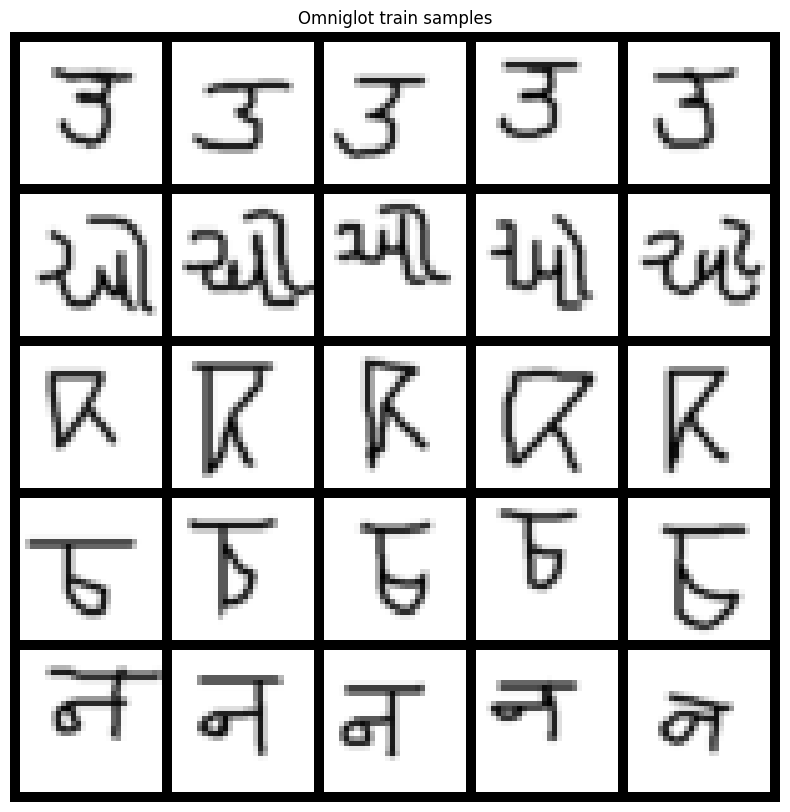

In [20]:
from collections import defaultdict
from torchvision.datasets import Omniglot
from sklearn.manifold import TSNE

omniglot_root = os.path.join("Assignment6", "data", "omniglot")
omniglot_tf = transforms.Compose([
    transforms.Resize((28, 28), interpolation=InterpolationMode.BILINEAR),
    transforms.ToTensor(),
])

train_omniglot = Omniglot(root=omniglot_root, background=True, download=True, transform=omniglot_tf)
test_omniglot = Omniglot(root=omniglot_root, background=False, download=True, transform=omniglot_tf)


def build_class_to_indices(ds):
    class_to_indices = defaultdict(list)
    for idx in range(len(ds)):
        _, y = ds[idx]
        class_to_indices[int(y)].append(idx)
    return dict(class_to_indices)


train_class_to_indices = build_class_to_indices(train_omniglot)
test_class_to_indices = build_class_to_indices(test_omniglot)

print(f"Train classes: {len(train_class_to_indices)}")
print(f"Test classes: {len(test_class_to_indices)}")
print(f"Images per train class: {len(next(iter(train_class_to_indices.values())))}")


def plot_omniglot_gallery(ds, class_to_indices, n_classes=5, n_samples=5, seed=42, title="Omniglot samples"):
    rng = np.random.default_rng(seed)
    classes = rng.choice(list(class_to_indices.keys()), size=n_classes, replace=False)
    images = []
    for cls in classes:
        idxs = rng.choice(class_to_indices[cls], size=n_samples, replace=False)
        for idx in idxs:
            img, _ = ds[idx]
            images.append(img)
    grid = make_grid(images, nrow=n_samples, padding=2).cpu()
    plt.figure(figsize=(n_samples * 2, n_classes * 2))
    if grid.shape[0] == 1:
        plt.imshow(grid.squeeze(0), cmap="gray")
    else:
        plt.imshow(grid.permute(1, 2, 0))
    plt.axis("off")
    plt.title(title)
    plt.show()


plot_omniglot_gallery(
    train_omniglot,
    train_class_to_indices,
    n_classes=5,
    n_samples=5,
    seed=1,
    title="Omniglot train samples",
)


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

    def forward(self, x):
        return self.net(x)


class ProtoNetEncoder(nn.Module):
    def __init__(self, in_channels=1, hidden_channels=64, embedding_dim=64):
        super().__init__()
        self.blocks = nn.Sequential(
            ConvBlock(in_channels, hidden_channels),
            ConvBlock(hidden_channels, hidden_channels),
            ConvBlock(hidden_channels, hidden_channels),
            ConvBlock(hidden_channels, embedding_dim),
        )

    def forward(self, x):
        x = self.blocks(x)
        return x.view(x.size(0), -1)


def pairwise_squared_euclidean(x, y):
    x2 = (x ** 2).sum(dim=1, keepdim=True)
    y2 = (y ** 2).sum(dim=1, keepdim=True).t()
    return x2 + y2 - 2 * (x @ y.t())


def sample_episode(dataset, class_to_indices, n_way, n_shot, n_query, rng):
    classes = rng.choice(list(class_to_indices.keys()), size=n_way, replace=False)
    support_images = []
    query_images = []
    query_labels = []
    for epi_label, cls in enumerate(classes):
        indices = class_to_indices[cls]
        selected = rng.choice(indices, size=n_shot + n_query, replace=False)
        support_idx = selected[:n_shot]
        query_idx = selected[n_shot:]
        for idx in support_idx:
            img, _ = dataset[idx]
            support_images.append(img)
        for idx in query_idx:
            img, _ = dataset[idx]
            query_images.append(img)
            query_labels.append(epi_label)
    support = torch.stack(support_images).to(device)
    query = torch.stack(query_images).to(device)
    query_labels = torch.tensor(query_labels, dtype=torch.long, device=device)
    return support, query, query_labels


def run_episode(
    encoder,
    dataset,
    class_to_indices,
    n_way,
    n_shot,
    n_query,
    criterion,
    rng,
    train=True,
    return_embeddings=False,
):
    support, query, query_labels = sample_episode(
        dataset, class_to_indices, n_way, n_shot, n_query, rng
    )
    encoder.train() if train else encoder.eval()
    with torch.set_grad_enabled(train):
        support_emb = encoder(support)
        query_emb = encoder(query)
        prototypes = support_emb.view(n_way, n_shot, -1).mean(dim=1)
        dists = pairwise_squared_euclidean(query_emb, prototypes)
        logits = -dists
        loss = criterion(logits, query_labels)
    preds = logits.argmax(dim=1)
    acc = (preds == query_labels).float().mean().item()
    if return_embeddings:
        return loss, acc, query_emb, prototypes, query_labels
    return loss, acc


def moving_average(values, window=20):
    if len(values) < window:
        return np.array(values)
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")


def plot_episode_metrics(losses, accs, title, window=20):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(losses, alpha=0.3, label="raw")
    axes[1].plot(accs, alpha=0.3, label="raw")
    if len(losses) >= window:
        axes[0].plot(moving_average(losses, window), label=f"ma{window}")
        axes[1].plot(moving_average(accs, window), label=f"ma{window}")
    axes[0].set_title("Episode loss")
    axes[1].set_title("Episode accuracy")
    axes[0].set_xlabel("Episode")
    axes[1].set_xlabel("Episode")
    axes[0].legend()
    axes[1].legend()
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def train_protonet(
    encoder,
    dataset,
    class_to_indices,
    n_way,
    n_shot,
    n_query,
    episodes=600,
    lr=1e-3,
    seed=42,
):
    encoder.to(device)
    optimizer = torch.optim.Adam(encoder.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    rng = np.random.default_rng(seed)
    losses = []
    accs = []
    for ep in range(1, episodes + 1):
        loss, acc = run_episode(
            encoder,
            dataset,
            class_to_indices,
            n_way,
            n_shot,
            n_query,
            criterion,
            rng,
            train=True,
        )
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        accs.append(acc)
        if ep % 100 == 0:
            print(f"Episode {ep}/{episodes} - loss: {loss.item():.4f}, acc: {acc:.4f}")
    return losses, accs


def evaluate_protonet(
    encoder,
    dataset,
    class_to_indices,
    n_way,
    n_shot,
    n_query,
    episodes=100,
    seed=123,
):
    encoder.eval()
    criterion = nn.CrossEntropyLoss()
    rng = np.random.default_rng(seed)
    accs = []
    with torch.no_grad():
        for _ in range(episodes):
            loss, acc = run_episode(
                encoder,
                dataset,
                class_to_indices,
                n_way,
                n_shot,
                n_query,
                criterion,
                rng,
                train=False,
            )
            accs.append(acc)
    mean_acc = float(np.mean(accs))
    std_acc = float(np.std(accs))
    return mean_acc, std_acc, accs


def tsne_episode_plot(
    encoder,
    dataset,
    class_to_indices,
    n_way,
    n_shot,
    n_query,
    seed=7,
    title="t-SNE",
):
    rng = np.random.default_rng(seed)
    encoder.eval()
    with torch.no_grad():
        support, query, query_labels = sample_episode(
            dataset, class_to_indices, n_way, n_shot, n_query, rng
        )
        support_emb = encoder(support)
        query_emb = encoder(query)
        prototypes = support_emb.view(n_way, n_shot, -1).mean(dim=1)

    all_emb = torch.cat([query_emb, prototypes], dim=0).cpu().numpy()
    n_samples = all_emb.shape[0]
    perplexity = min(30, n_samples - 1)
    tsne = TSNE(n_components=2, random_state=seed, init="pca", perplexity=perplexity)
    coords = tsne.fit_transform(all_emb)
    q_coords = coords[: len(query_emb)]
    p_coords = coords[len(query_emb) :]
    query_labels_np = query_labels.cpu().numpy()

    plt.figure(figsize=(6, 5))
    for cls in range(n_way):
        mask = query_labels_np == cls
        plt.scatter(q_coords[mask, 0], q_coords[mask, 1], s=20, label=f"Class {cls}")
        plt.scatter(
            p_coords[cls, 0],
            p_coords[cls, 1],
            s=200,
            marker="X",
            edgecolor="black",
        )
    plt.legend()
    plt.title(title)
    plt.tight_layout()
    plt.show()


n_way = 5
n_query = 15
train_episodes = 1000
eval_episodes = 100



=== 5-way 1-shot ===
Episode 100/1000 - loss: 0.2948, acc: 0.8933
Episode 200/1000 - loss: 0.3020, acc: 0.8800
Episode 300/1000 - loss: 0.3578, acc: 0.8400
Episode 400/1000 - loss: 0.2393, acc: 0.8933
Episode 500/1000 - loss: 0.0310, acc: 1.0000
Episode 600/1000 - loss: 0.0957, acc: 0.9600
Episode 700/1000 - loss: 0.3020, acc: 0.8667
Episode 800/1000 - loss: 0.1156, acc: 0.9600
Episode 900/1000 - loss: 0.1253, acc: 0.9733
Episode 1000/1000 - loss: 0.1112, acc: 0.9600


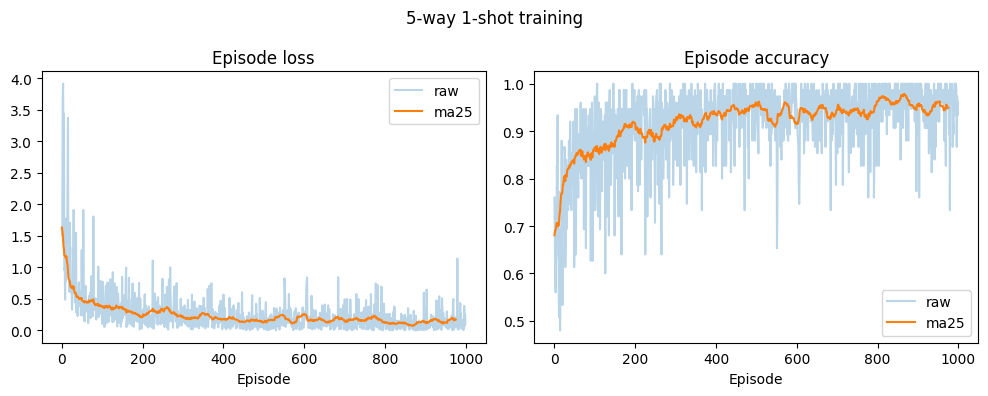

Test mean acc: 0.9067 +/- 0.1459 (2 std)


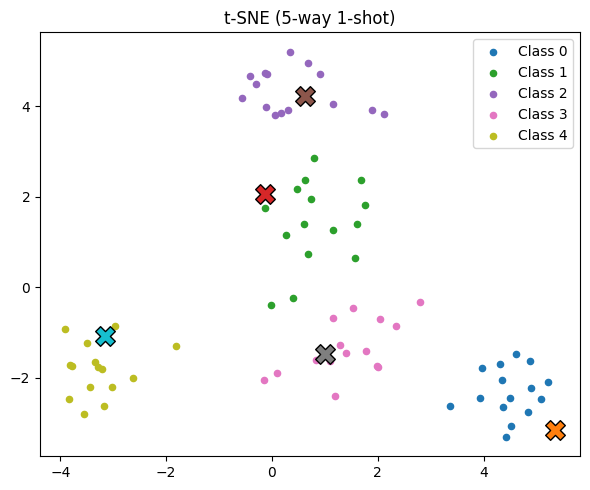

In [21]:
n_shot = 1
results_fewshot = {}

print(f"\n=== {n_way}-way {n_shot}-shot ===")
encoder_1shot = ProtoNetEncoder()
train_losses_1, train_accs_1 = train_protonet(
    encoder_1shot,
    train_omniglot,
    train_class_to_indices,
    n_way,
    n_shot,
    n_query,
    episodes=train_episodes,
    lr=1e-3,
    seed=42,
)
plot_episode_metrics(
    train_losses_1,
    train_accs_1,
    title=f"{n_way}-way {n_shot}-shot training",
    window=25,
)
mean_acc_1, std_acc_1, accs_1 = evaluate_protonet(
    encoder_1shot,
    test_omniglot,
    test_class_to_indices,
    n_way,
    n_shot,
    n_query,
    episodes=eval_episodes,
    seed=123,
)
print(f"Test mean acc: {mean_acc_1:.4f} +/- {2 * std_acc_1:.4f} (2 std)")
tsne_episode_plot(
    encoder_1shot,
    test_omniglot,
    test_class_to_indices,
    n_way,
    n_shot,
    n_query,
    seed=7,
    title=f"t-SNE ({n_way}-way {n_shot}-shot)",
)

results_fewshot[n_shot] = {
    "encoder": encoder_1shot,
    "train_losses": train_losses_1,
    "train_accs": train_accs_1,
    "mean_acc": mean_acc_1,
    "std_acc": std_acc_1,
    "accs": accs_1,
}
if device.type == "mps":
    torch.mps.empty_cache()



=== 5-way 5-shot ===
Episode 100/1000 - loss: 0.2511, acc: 0.9333
Episode 200/1000 - loss: 0.0134, acc: 1.0000
Episode 300/1000 - loss: 0.0861, acc: 0.9867
Episode 400/1000 - loss: 0.0412, acc: 0.9733
Episode 500/1000 - loss: 0.0075, acc: 1.0000
Episode 600/1000 - loss: 0.0844, acc: 0.9733
Episode 700/1000 - loss: 0.0013, acc: 1.0000
Episode 800/1000 - loss: 0.0034, acc: 1.0000
Episode 900/1000 - loss: 0.0100, acc: 1.0000
Episode 1000/1000 - loss: 0.0038, acc: 1.0000


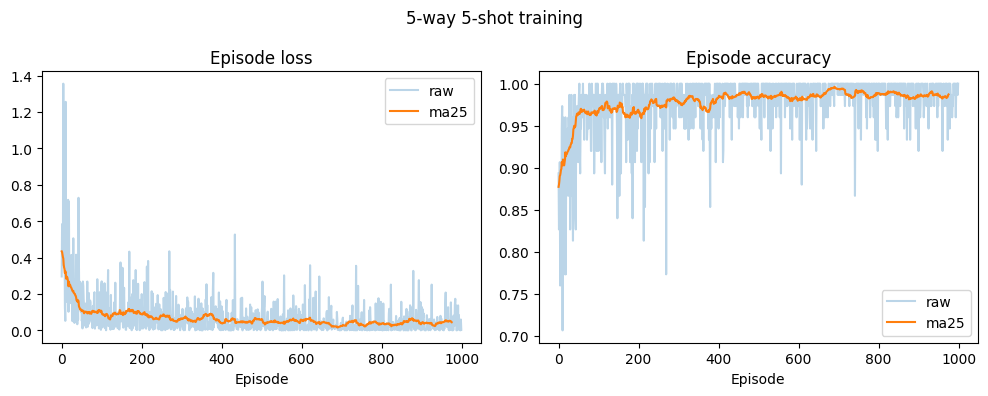

Test mean acc: 0.9695 +/- 0.0662 (2 std)


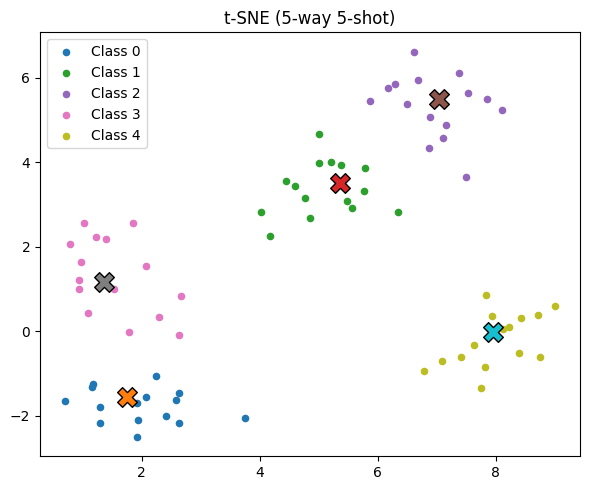

In [22]:
n_shot = 5

print(f"\n=== {n_way}-way {n_shot}-shot ===")
encoder_5shot = ProtoNetEncoder()
train_losses_5, train_accs_5 = train_protonet(
    encoder_5shot,
    train_omniglot,
    train_class_to_indices,
    n_way,
    n_shot,
    n_query,
    episodes=train_episodes,
    lr=1e-3,
    seed=42,
)
plot_episode_metrics(
    train_losses_5,
    train_accs_5,
    title=f"{n_way}-way {n_shot}-shot training",
    window=25,
)
mean_acc_5, std_acc_5, accs_5 = evaluate_protonet(
    encoder_5shot,
    test_omniglot,
    test_class_to_indices,
    n_way,
    n_shot,
    n_query,
    episodes=eval_episodes,
    seed=123,
)
print(f"Test mean acc: {mean_acc_5:.4f} +/- {2 * std_acc_5:.4f} (2 std)")
tsne_episode_plot(
    encoder_5shot,
    test_omniglot,
    test_class_to_indices,
    n_way,
    n_shot,
    n_query,
    seed=7,
    title=f"t-SNE ({n_way}-way {n_shot}-shot)",
)

results_fewshot[n_shot] = {
    "encoder": encoder_5shot,
    "train_losses": train_losses_5,
    "train_accs": train_accs_5,
    "mean_acc": mean_acc_5,
    "std_acc": std_acc_5,
    "accs": accs_5,
}
if device.type == "mps":
    torch.mps.empty_cache()


In [23]:
rows = []
for shot, metrics in results_fewshot.items():
    rows.append({
        "n_way": n_way,
        "n_shot": shot,
        "n_query": n_query,
        "train_episodes": train_episodes,
        "eval_episodes": eval_episodes,
        "mean_acc": round(metrics["mean_acc"], 4),
        "std_acc": round(metrics["std_acc"], 4),
        "acc_2std": round(2 * metrics["std_acc"], 4),
    })

results_fewshot_df = pd.DataFrame(rows).sort_values("n_shot")
results_fewshot_df


,n_way,n_shot,n_query,train_episodes,eval_episodes,mean_acc,std_acc,acc_2std
0,5,1,15,1000,100,0.9067,0.0729,0.1459
1,5,5,15,1000,100,0.9695,0.0331,0.0662


- 5-shot achieves higher mean accuracy and lower variance than 1-shot, which matches the benefit of more support examples.
- Training curves stabilize faster for 5-shot, while 1-shot remains noisier across episodes.
- t-SNE shows tighter clusters for 5-shot; 1-shot clusters are separable but more dispersed.